# 课程设计 · 交互式复现
## 基于 LDA 主题模型的中文科技 RSS 语料主题挖掘

复现论文：**Blei, Ng & Jordan (2003), Latent Dirichlet Allocation, JMLR**。

本 Notebook 复用作业 1 的语料与作业 2 的定制化分词词典，依次执行：分词 → 词袋 → 选 K → 训练 LDA → 展示主题与可视化。完整流水线见 `../hw3_pipeline.py`。

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

BASE = Path.cwd().parent          # 课程设计/
sys.path.insert(0, str(BASE))
import hw3_pipeline as h
FIG, DATA = BASE / 'figures', BASE / 'data'
print('working base:', BASE)

working base: /Users/l1nsn0w/Desktop/Projects/text_mining/课程设计


### 1. 载入语料 + 加载作业 2 定制词典分词（联动作业 1、2）

In [2]:
docs = h.load_docs()
stopwords = h.load_stopwords()
tk = h.build_tokenizer()                       # 加载 ../../作业 2/data/custom_dict_final.txt
tokens = h.tokenize(docs, tk, stopwords)
dictionary, corpus = h.build_corpus(tokens)
print(f'文档={len(docs)}  含日期={sum(d.date is not None for d in docs)}  停用词={len(stopwords)}')
print(f'总 token={sum(len(t) for t in tokens)}  词表(filter_extremes 后)={len(dictionary)}')

Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/r0/sz1_yf4n7y3gm6n6ddtzv3xr0000gn/T/jieba.cache


Loading model cost 0.228 seconds.


Prefix dict has been built successfully.


文档=221  含日期=188  停用词=767
总 token=46456  词表(filter_extremes 后)=1845


### 2. 选择主题数 K：困惑度 + C_v 一致性

（扫描结果已由 `hw3_pipeline.py` 保存；下方直接展示曲线与数值表。重新扫描可调用 `h.scan_k(corpus, dictionary, tokens)`。）

,k,coherence_cv,perplexity,log_perplexity
0,4,0.2950,138.05,-7.1090
1,5,0.2981,136.86,-7.0966
2,6,0.3415,136.86,-7.0966
3,7,0.3409,138.38,-7.1124
4,8,0.3388,140.84,-7.1379
5,9,0.3956,141.60,-7.1456
6,10,0.4169,142.23,-7.1521
7,12,0.3857,142.79,-7.1577


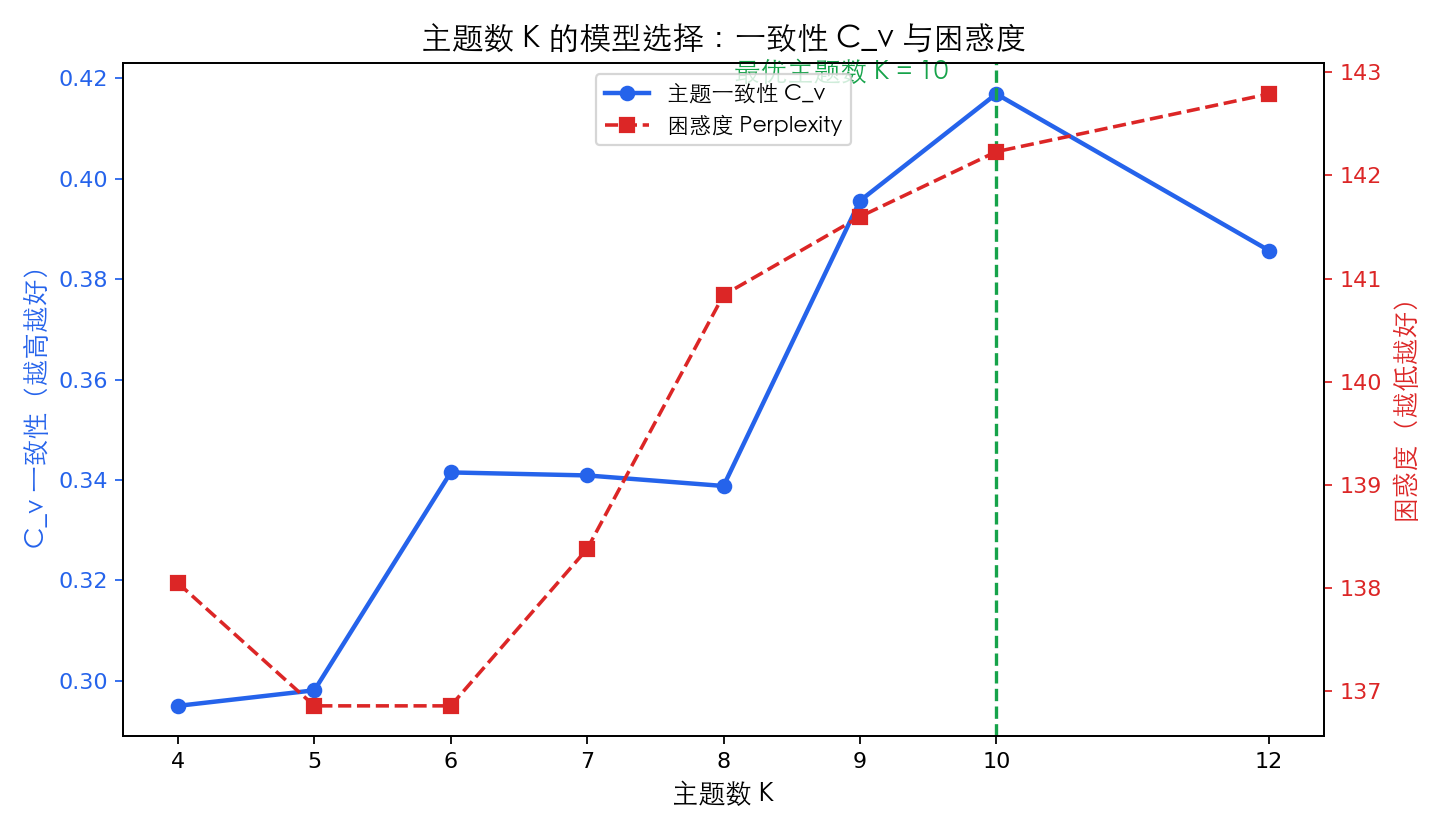

In [3]:
display(pd.read_csv(DATA / 'coherence_scan.csv'))
display(Image(filename=str(FIG / 'k_selection.png')))

### 3. 训练最终 LDA（K=10）并查看各主题关键词

In [4]:
model = h.train_lda(corpus, dictionary, 10)
labels = h.load_labels(10, model)
for t in range(10):
    terms = ' '.join(w for w, _ in model.show_topic(t, 10))
    print(f"T{t} [{labels[t]}]: {terms}")

T0 [开源小模型]: Gemma 模型 Google 参数 本地 推理 开源 31B 开放 Agent
T1 [软件与外设]: 耳机 镜像 降噪 OpenClaw 下载 Pro Windows 模型 生态 开发者
T2 [产业AI落地]: 企业 模型 Token 全球 智能 大模型 汽车 场景 安全 小米
T3 [AI编程助手]: 模型 大模型 智能 编程 Claude 工具 任务 小龙虾 全球 开源
T4 [生成式AI]: OpenClaw Claude Anthropic 工具 Code Image 模型 生成 文件 第三方
T5 [AI芯片算力]: 芯片 Max 英伟达 品牌 AirPods 成本 Token 声音 智能 算力
T6 [自动驾驶]: 安全 自动 会议 驾驶 车辆 视频 录制 腾讯 触发 场景
T7 [激光雷达]: 激光雷达 团队 skill 研发 方案 智能 机器人 场景 企业 竞争
T8 [游戏与数码]: 游戏 耳机 有线 玩家 充电 感受 视频 个人 东西 创作
T9 [苹果生态]: 苹果 Mac App 免费 代码 Coding 工具 开源 Store iPhone


### 4. 可视化总览

主题关键词 / 词云 / 主题间距离图 / 主题×来源 / 每日主题构成 / 作业 2 新词归属。

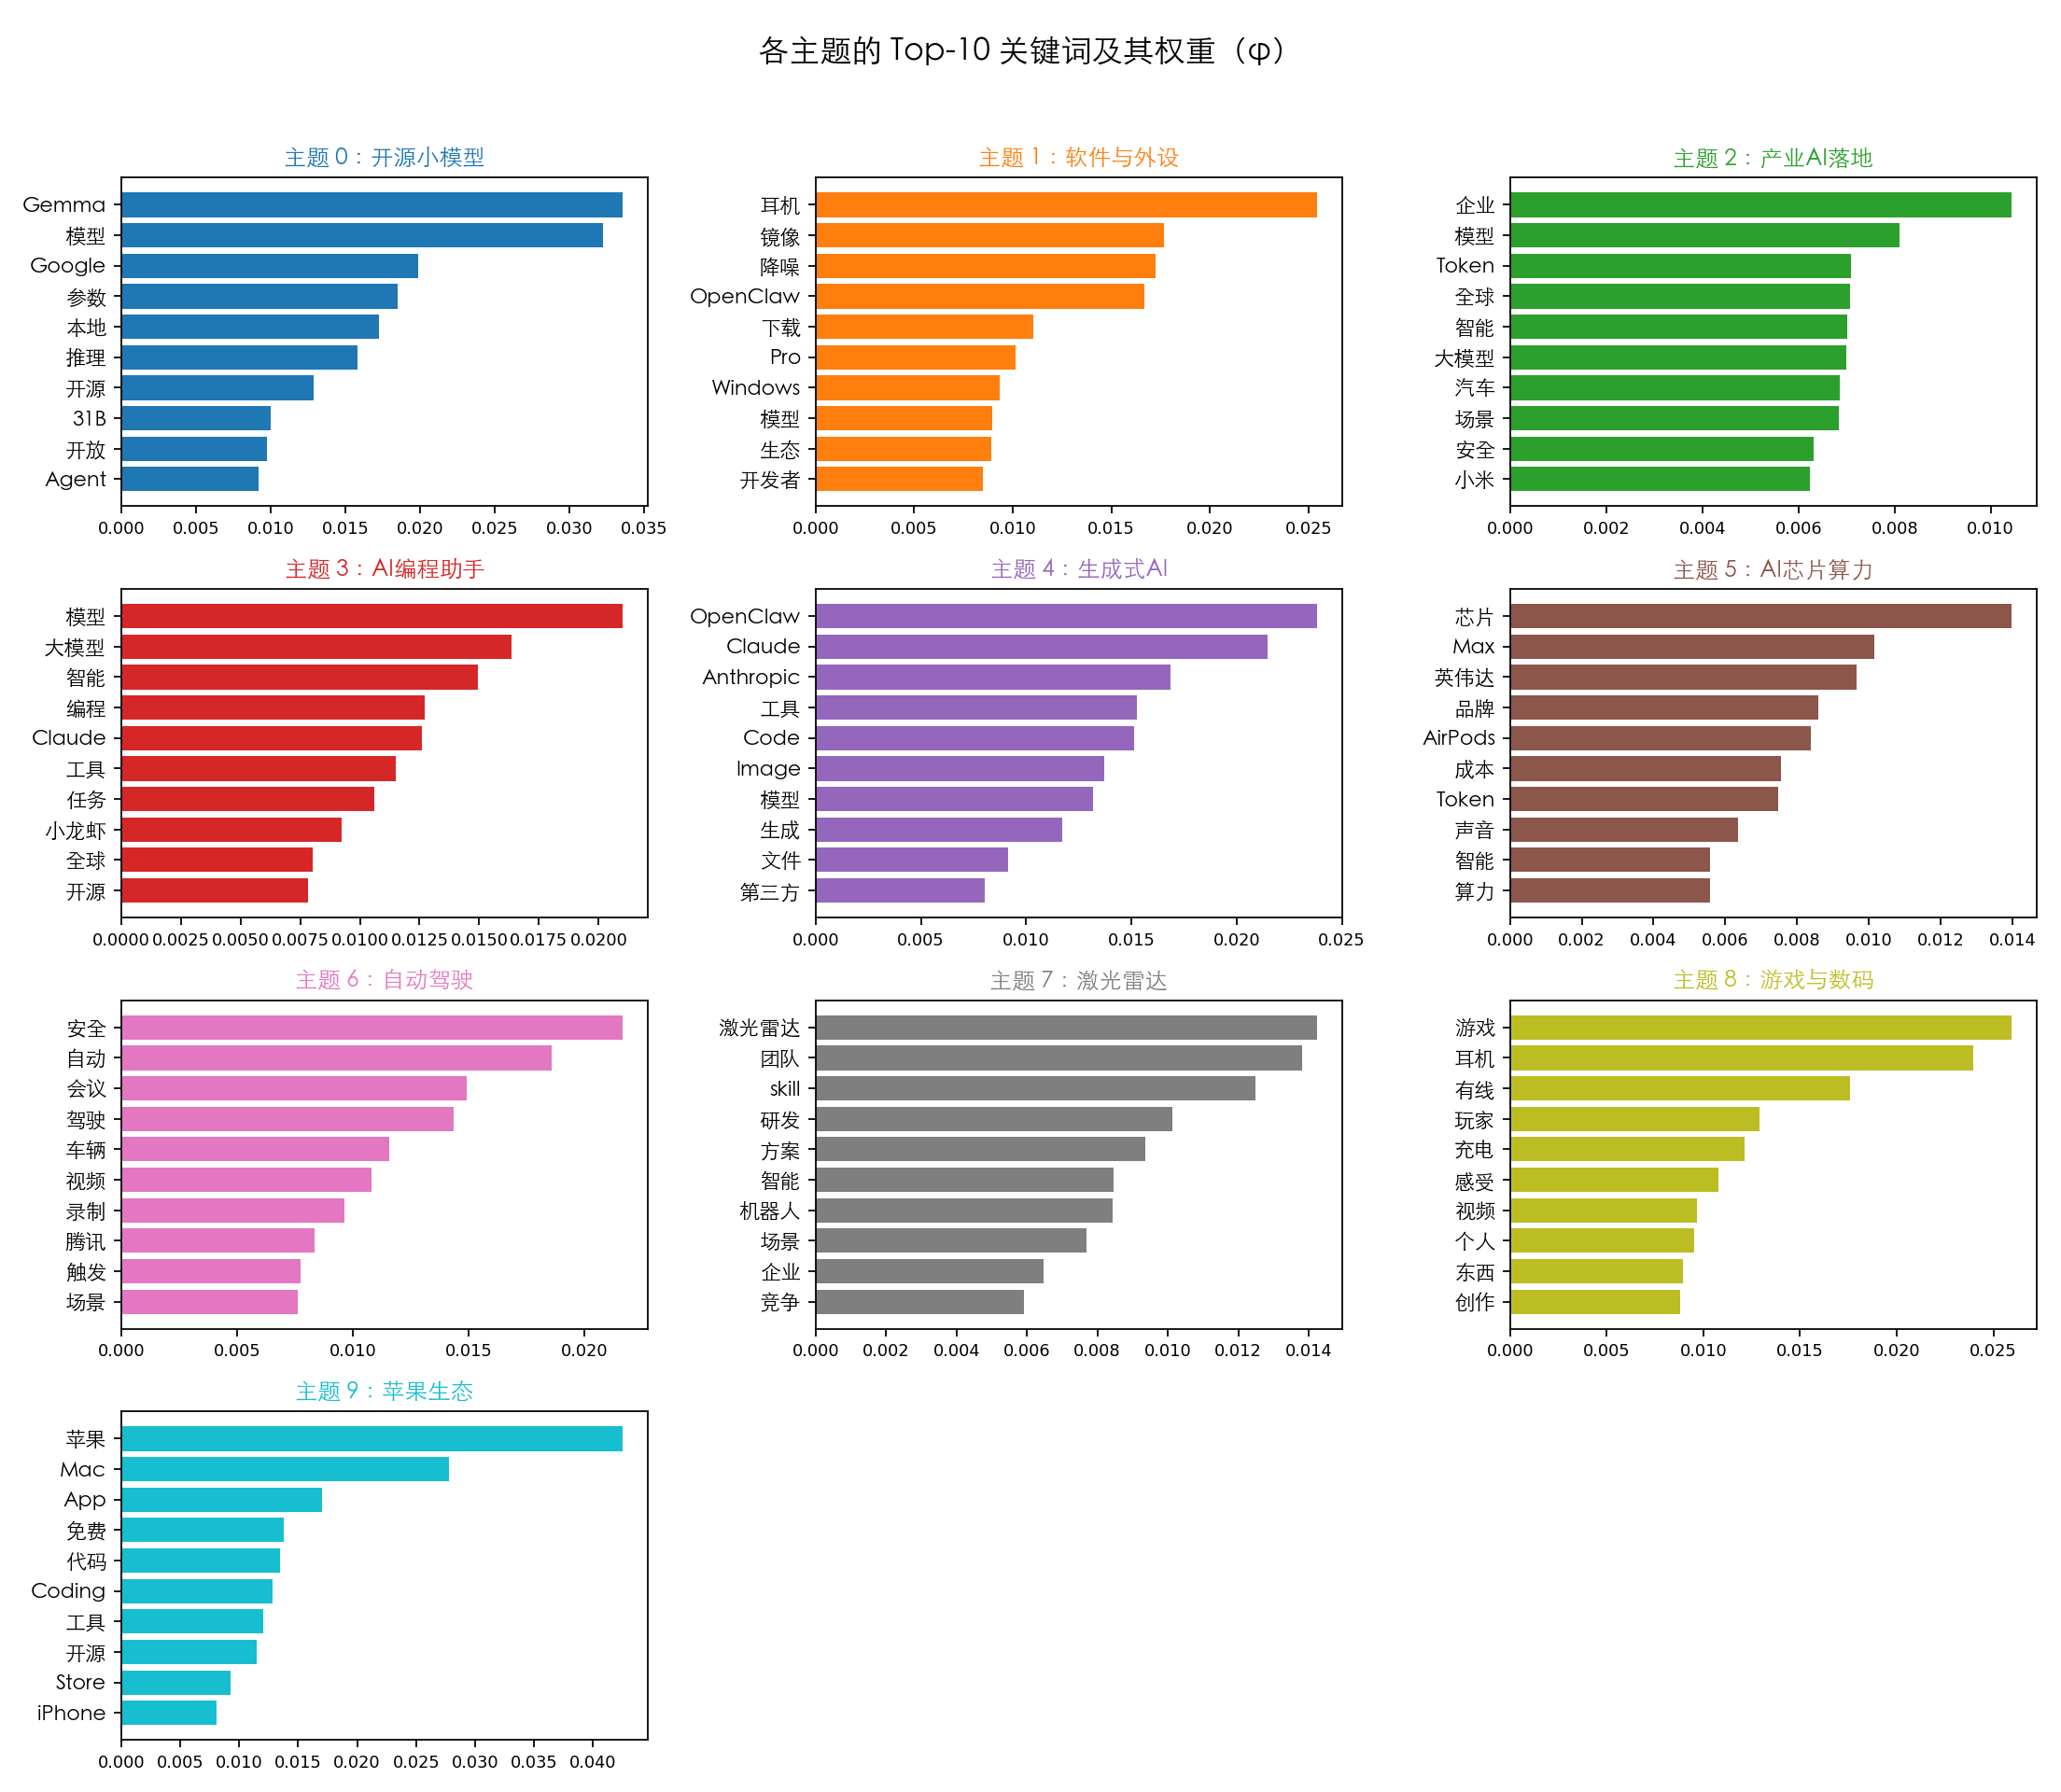

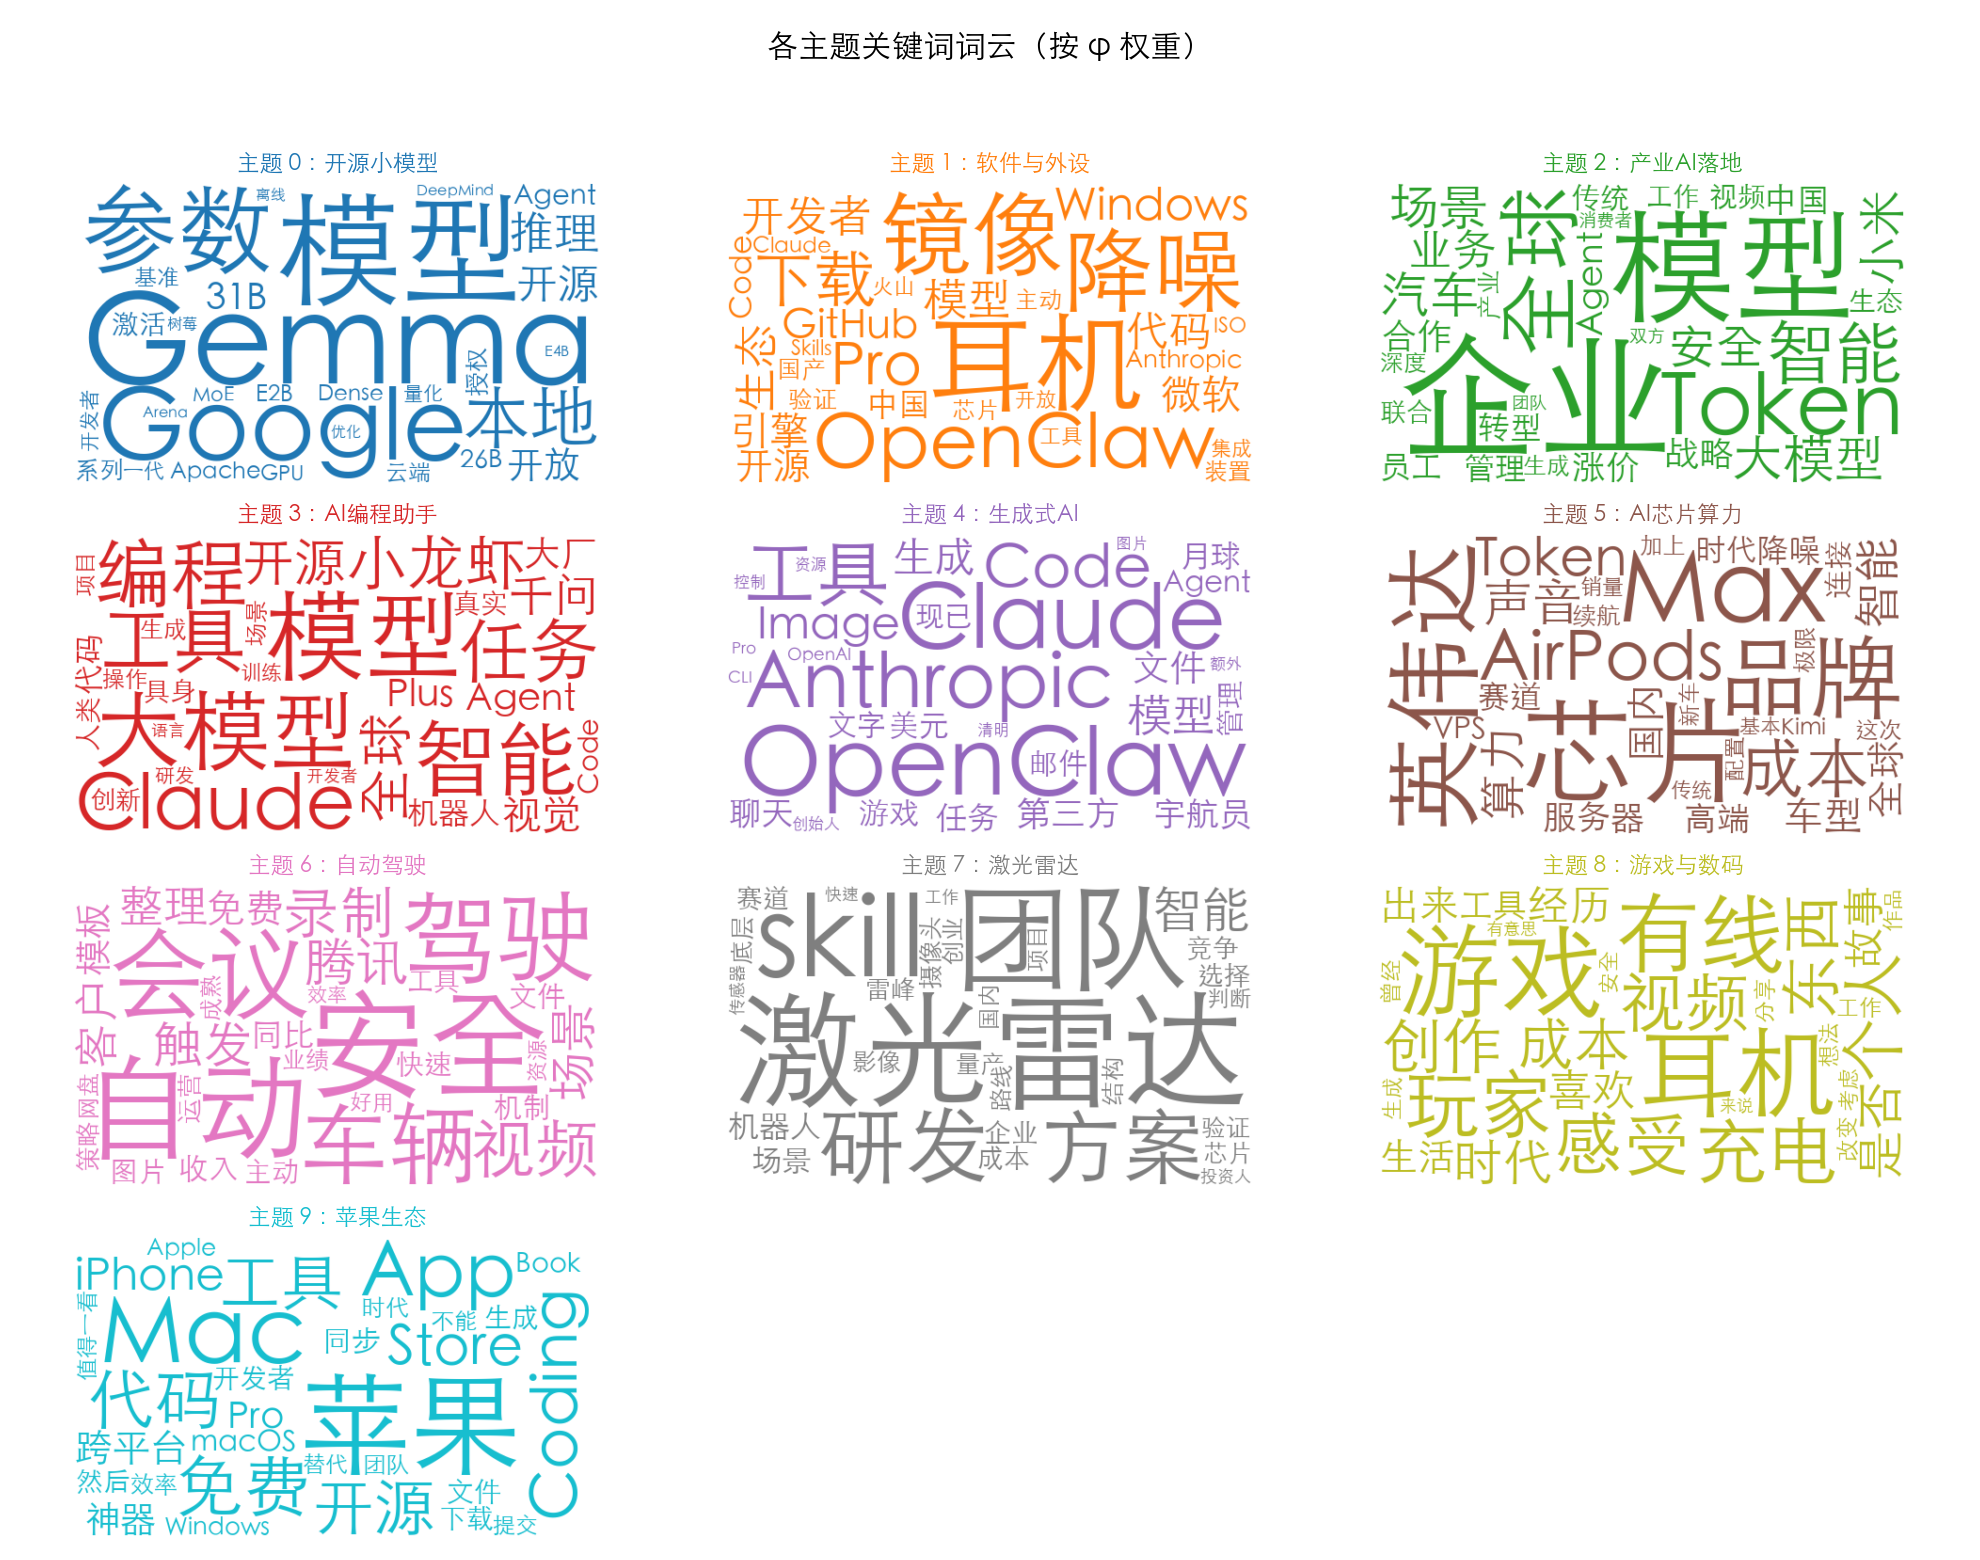

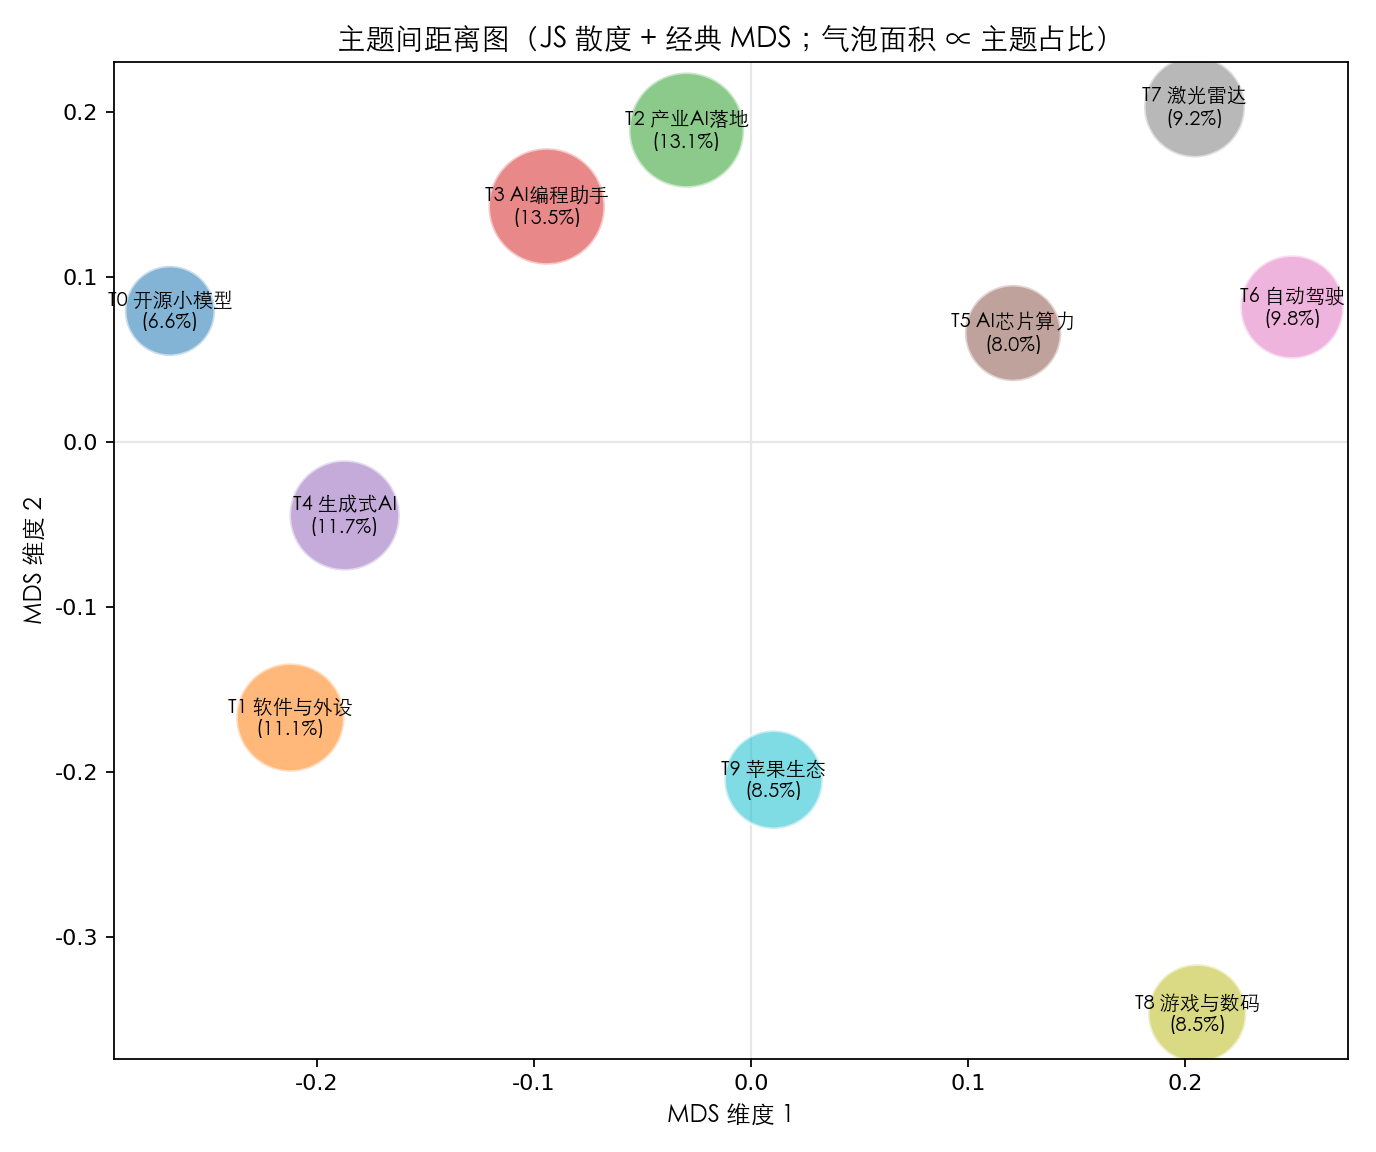

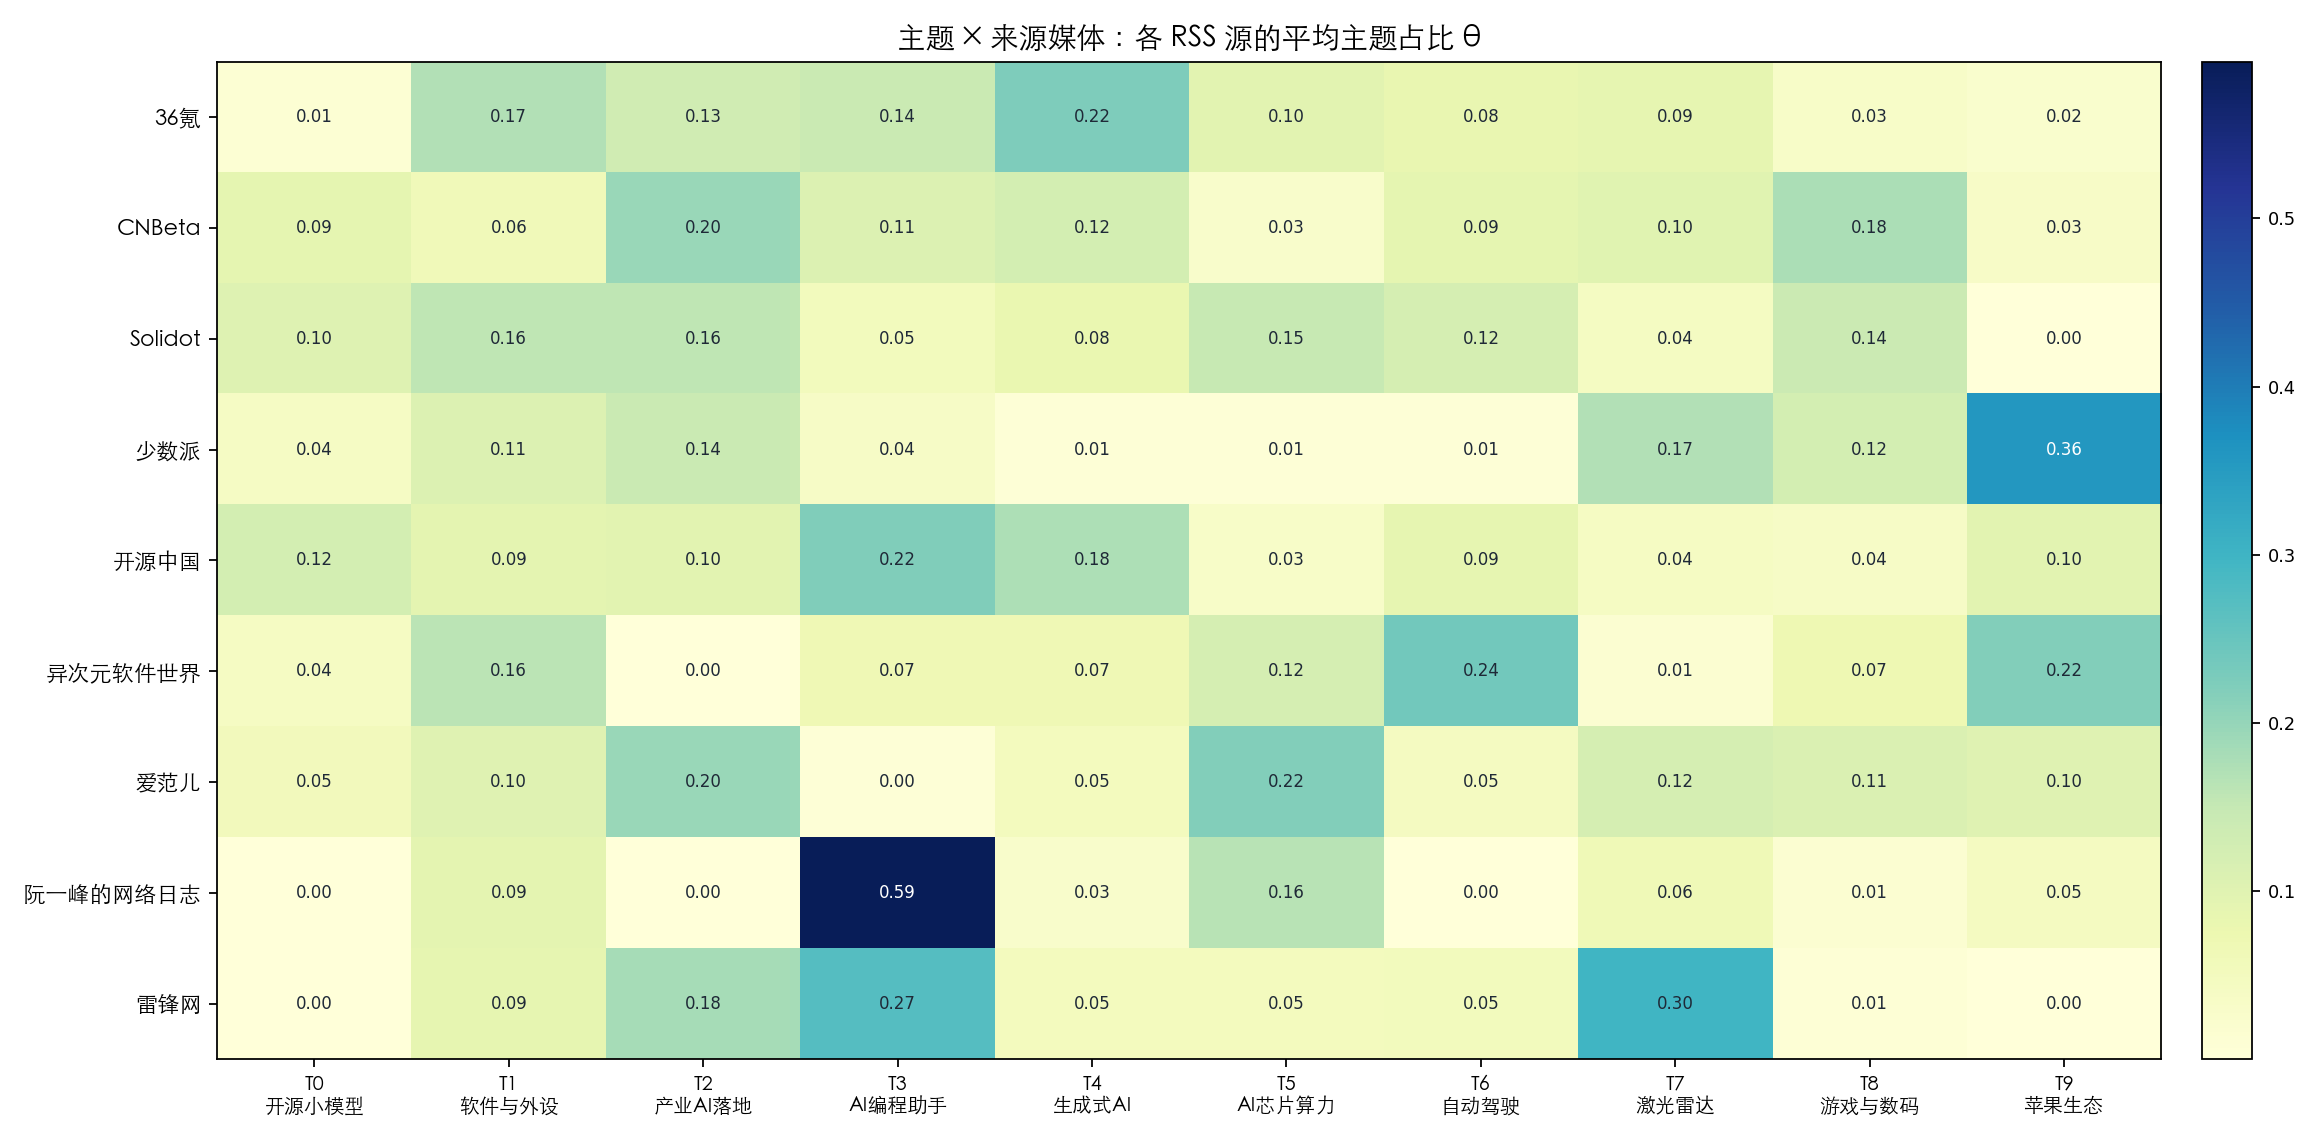

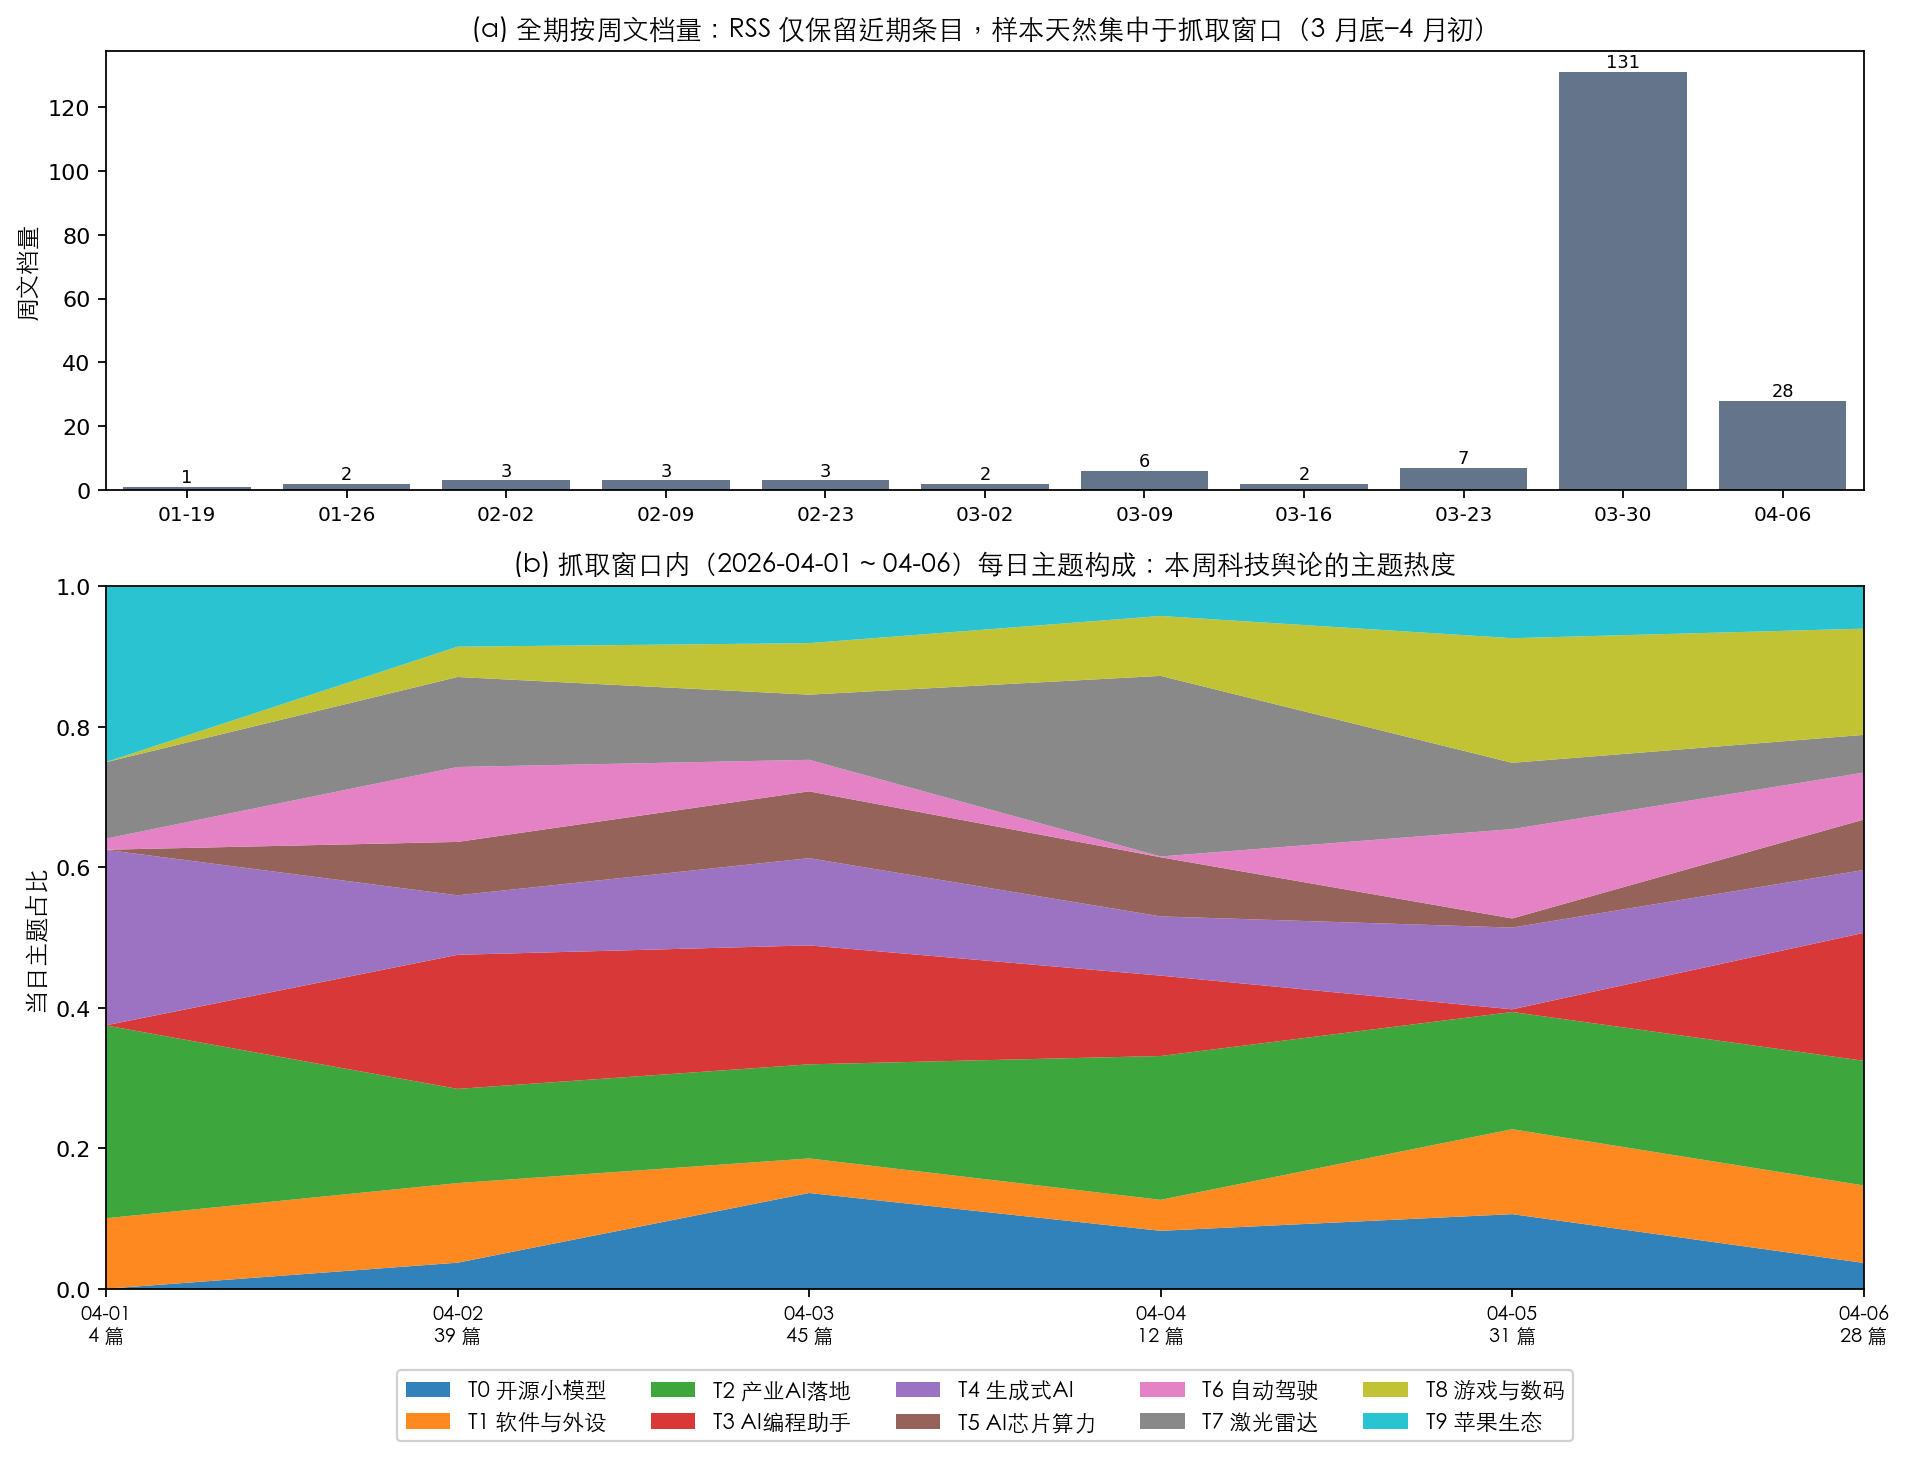

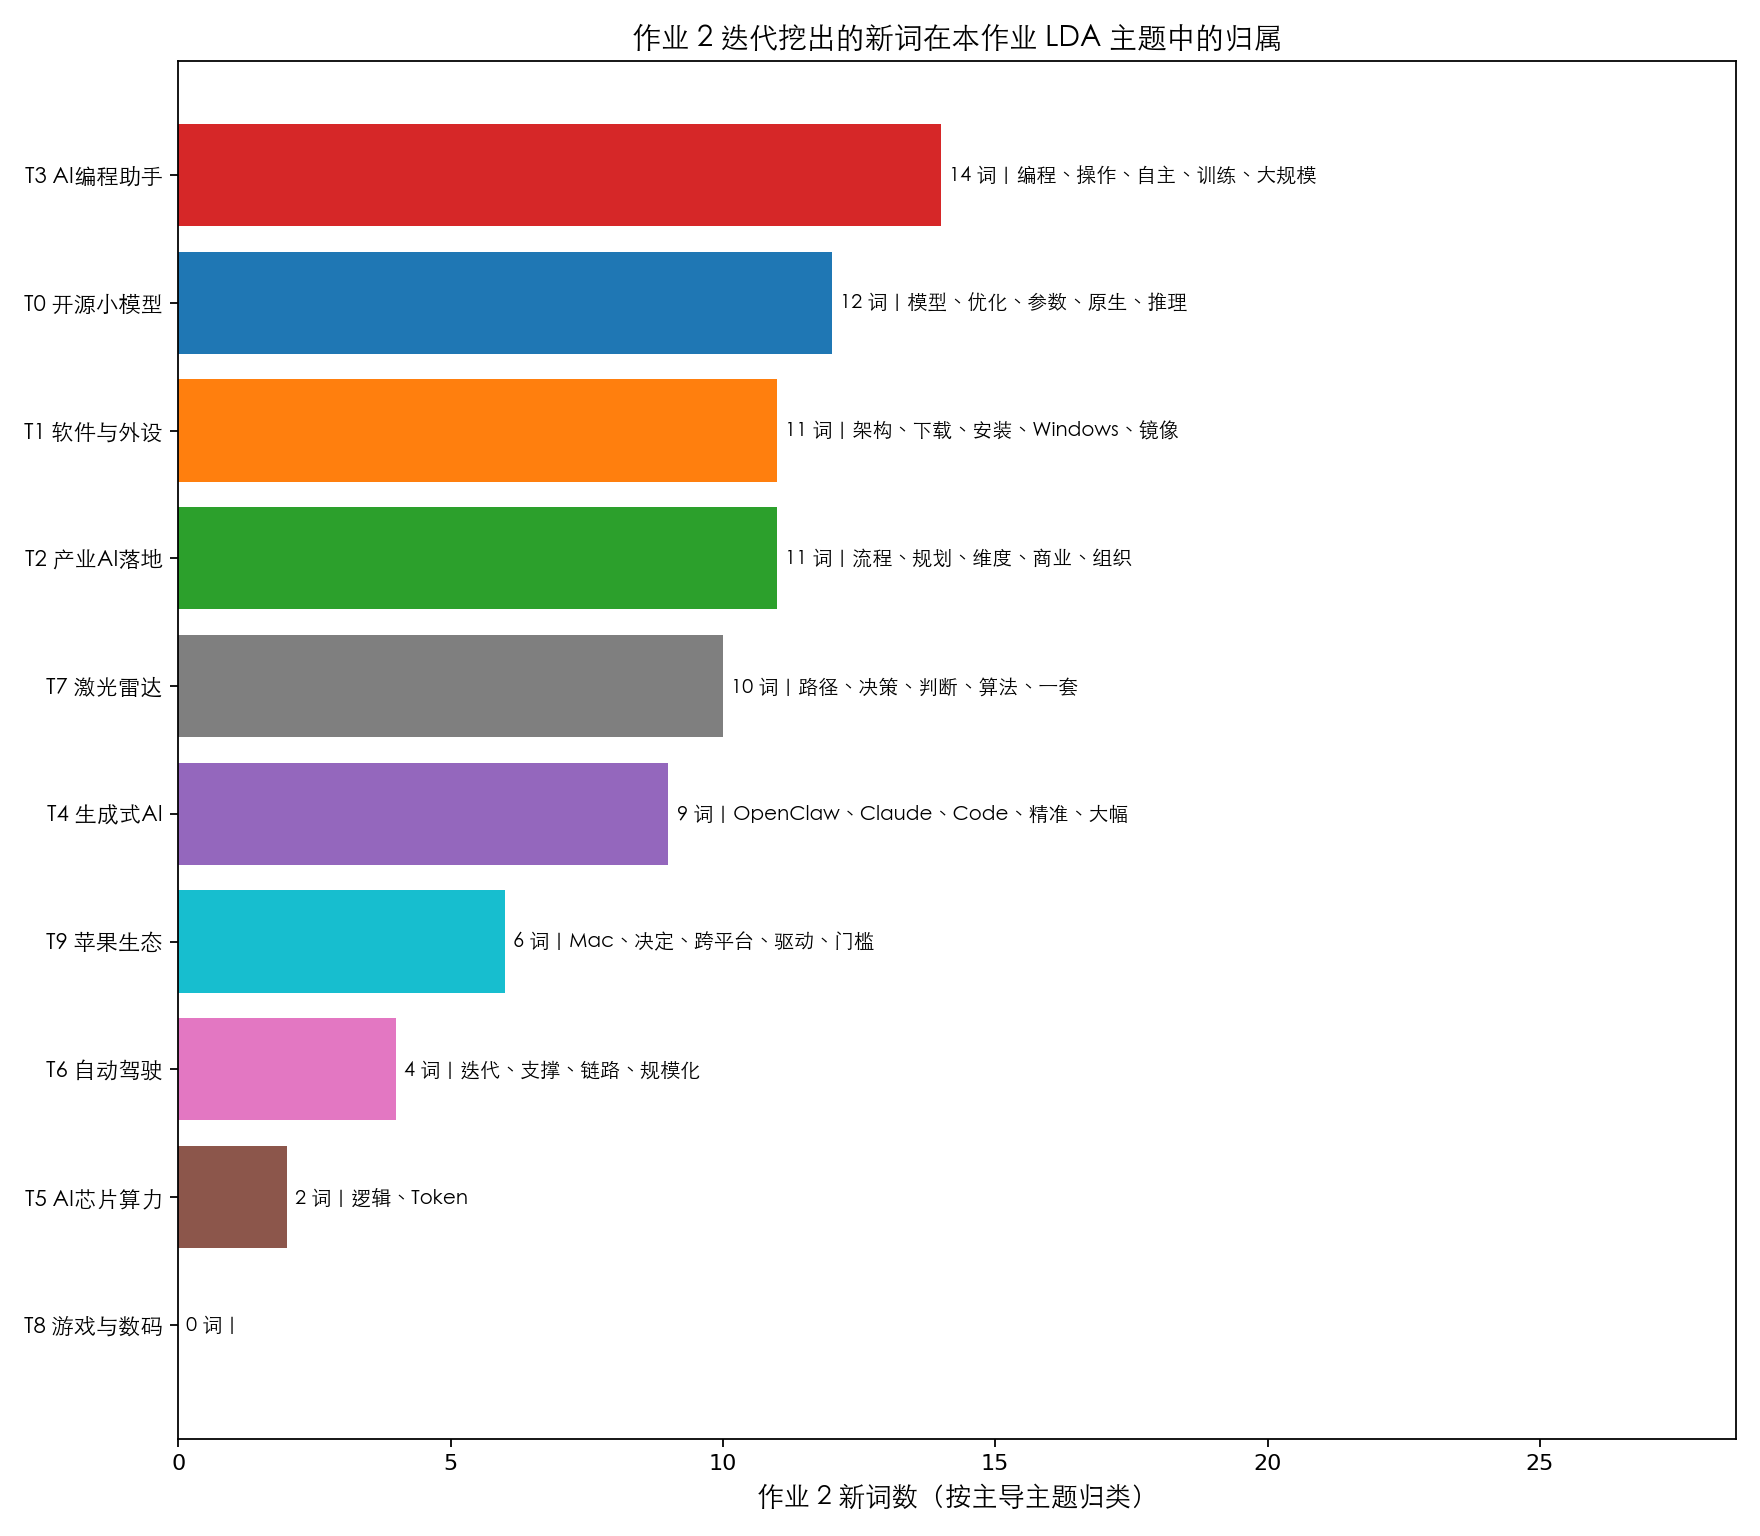

In [5]:
for name in ['topic_terms', 'topic_wordclouds', 'intertopic_map',
             'topic_source_heatmap', 'topic_timeline', 'newword_bridge']:
    display(Image(filename=str(FIG / f'{name}.png')))

### 5. 作业 2 新词 → 本作业主题 的归属（联动收束）

In [6]:
nw = pd.read_csv(DATA / 'newword_topic.csv')
print(f'作业 2 新词被主题吸纳：{len(nw)} 个')
nw.groupby('dominant_label').size().sort_values(ascending=False).to_frame('新词数')

作业 2 新词被主题吸纳：79 个


,新词数
dominant_label,
AI编程助手,14
开源小模型,12
产业AI落地,11
软件与外设,11
激光雷达,10
生成式AI,9
苹果生态,6
自动驾驶,4
AI芯片算力,2
